# Experiment 01 — Prompt Strategy Comparison Across Models

This notebook evaluates how two fundamentally different **prompting strategies** affect classification quality across three models on all 10 DMP samples.

---

## Experiment context

The `dmpbridge` pipeline labels PDF text blocks with one of five labels:  
`title` · `section.title` · `section.description` · `question.text` · `answer.text`

The core challenge is distinguishing **`question.text`** (funder requirement text) from **`section.description`** (funder background/context) — both are multi-line funder-written text with similar phrasing, and their boundary is inherently structural.

---

## Prompt strategies

| Strategy | Description | Context available to model |
|---|---|---|
| **Batch** | 10 blocks per API call with a 3-block sliding context window | Narrow window — model sees surrounding 3 blocks only |
| **Whole-doc** | All blocks in a single API call | Full document — model sees all blocks and their positions |

## Models under test

| Model | Provider | Size | Tag (batch) | Tag (whole-doc) |
|---|---|---|---|---|
| **llama3.3:70b** | Ollama (local) | 70B Q4 | `llama3.3-70b` | `llama3.3-70b-wholedoc` |
| **llama3.1:8b** | Ollama (local) | 8B Q4 | `llama3.1-8b` | `llama3.1-8b-wholedoc` |
| **claude-opus-4-8** | Anthropic API | — | `claude-opus-4-8` | `claude-opus-4-8-wholedoc` |

## Hypothesis

> Full-document context should significantly improve `question.text` F1 because the model can see the structural boundary between section descriptions and question lists — something a 10-block window cannot reliably capture.

---

## Notebook sections

1. **Availability check** — which variants have data for which samples
2. **Overall accuracy** — summary table across all 10 samples, all 6 variants
3. **Per-sample accuracy** — bar chart + heatmap
4. **F1 per label** — where each model/strategy succeeds and fails
5. **Prompt strategy delta** — batch → whole-doc accuracy change, per model
6. **Block-level analysis** — which blocks change and why
7. **Summary and conclusions**

---
## Setup

In [1]:
import sys, json
sys.path.insert(0, "../..")

from evaluate import extract_gold, evaluate_sample, match, LABELS, SHORT, LLM_DIR, MANUAL_DIR
from collections import defaultdict
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

sns.set_theme(style="ticks", palette="muted")
plt.rcParams.update({
    "figure.facecolor": "white",  "axes.facecolor": "white",
    "axes.edgecolor":   "#555",   "axes.linewidth": 0.8,
    "grid.color":       "#ddd",   "grid.linewidth": 0.5,
    "text.color":       "#111",   "axes.labelcolor": "#111",
    "xtick.color":      "#111",   "ytick.color": "#111",
    "font.size": 11,  "axes.titlesize": 13,  "axes.labelsize": 11,
    "xtick.labelsize": 10,        "ytick.labelsize": 10,
    "legend.fontsize": 10,        "legend.frameon": True,
    "figure.dpi": 120,
})

# ── Model family definitions ────────────────────────────────────────────────────
# Each family has a batch and a whole-doc variant.
# Colors: dark shade = batch, light shade = whole-doc (hatched)
MODEL_FAMILIES = {
    "llama3.3:70b": {
        "batch":     {"tag": "llama3.3-70b",            "color": "#1d4ed8", "hatch": None},
        "whole-doc": {"tag": "llama3.3-70b-wholedoc",   "color": "#60a5fa", "hatch": "//"},
    },
    "llama3.1:8b": {
        "batch":     {"tag": "llama3.1-8b",             "color": "#0369a1", "hatch": None},
        "whole-doc": {"tag": "llama3.1-8b-wholedoc",    "color": "#38bdf8", "hatch": "//"},
    },
    "claude-opus-4-8": {
        "batch":     {"tag": "claude-opus-4-8",          "color": "#7c3aed", "hatch": None},
        "whole-doc": {"tag": "claude-opus-4-8-wholedoc", "color": "#c084fc", "hatch": "//"},
    },
}

# Flat variant list preserving model-family order
VARIANTS = {}
for mname, methods in MODEL_FAMILIES.items():
    for method, cfg in methods.items():
        label = f"{mname} {method}"
        VARIANTS[label] = cfg

# ── Helpers ─────────────────────────────────────────────────────────────────────
def _snum(p):
    stem = p.stem if hasattr(p, "stem") else str(p)
    return int(stem.replace("_dmp", "").replace("sample", ""))

SAMPLES = sorted(MANUAL_DIR.glob("*_dmp.json"), key=_snum)
SNAMES  = [mp.stem.replace("_dmp", "") for mp in SAMPLES]

def _f1(conf, lbl):
    tp = conf.get(lbl, {}).get(lbl, 0)
    fp = sum(conf.get(o, {}).get(lbl, 0) for o in LABELS if o != lbl)
    fn = sum(v for p, v in conf.get(lbl, {}).items() if p != lbl)
    p_ = tp / (tp + fp) if (tp + fp) else 0.
    r_ = tp / (tp + fn) if (tp + fn) else 0.
    return 2 * p_ * r_ / (p_ + r_) if (p_ + r_) else 0.

def load_variant(tag):
    """Load all available samples for a given file tag.
    Returns (DataFrame with per-sample accuracy, aggregated confusion dict)
    or (None, None) if no files exist.
    """
    rows, conf = [], defaultdict(lambda: defaultdict(int))
    for mp in SAMPLES:
        stem = mp.stem.replace("_dmp", "")
        pp   = LLM_DIR / f"{stem}_{tag}.json"
        if not pp.exists(): continue
        gold = extract_gold(mp)
        c    = evaluate_sample(pp, gold)
        for tl, preds in c.items():
            for pl, cnt in preds.items():
                conf[tl][pl] += cnt
        tp = sum(c.get(l, {}).get(l, 0) for l in LABELS)
        n  = sum(sum(v.values()) for v in c.values())
        rows.append({"sample": stem, "total": n, "correct": tp,
                     "errors": n - tp, "accuracy": tp / n if n else 0})
    return (pd.DataFrame(rows), conf) if rows else (None, None)

# Load all variants
DATA = {name: load_variant(cfg["tag"]) for name, cfg in VARIANTS.items()}
ACTIVE = {n: d for n, d in DATA.items() if d[0] is not None}
print(f"Loaded {len(ACTIVE)} / {len(VARIANTS)} variants.")

Loaded 6 / 6 variants.


---
## Section 1 — Data availability

Confirms which variants have data for which samples. Variants marked `pending` need to be generated first (see `run_wholedoc_ollama.py`).

In [2]:
print(f"  {'Variant':<30}  {'Status':>10}  {'Samples':>7}  {'Correct':>7}  {'Total':>6}  {'Accuracy':>9}")
print("  " + "-" * 75)
for name, cfg in VARIANTS.items():
    df, _ = DATA[name]
    if df is None:
        print(f"  {name:<30}  {'pending':>10}  {'--':>7}  {'--':>7}  {'--':>6}  {'--':>9}")
    else:
        tc, tn = int(df["correct"].sum()), int(df["total"].sum())
        n_s = len(df)
        status = "OK" if n_s == 10 else f"partial ({n_s}/10)"
        print(f"  {name:<30}  {status:>10}  {n_s:>7}  {tc:>7}  {tn:>6}  {tc/tn*100:>8.1f}%")

  Variant                             Status  Samples  Correct   Total   Accuracy
  ---------------------------------------------------------------------------
  llama3.3:70b batch                      OK       10      697     741      94.1%
  llama3.3:70b whole-doc          partial (4/10)        4      360     397      90.7%
  llama3.1:8b batch                       OK       10      499     741      67.3%
  llama3.1:8b whole-doc                   OK       10      624     741      84.2%
  claude-opus-4-8 batch                   OK       10      703     741      94.9%
  claude-opus-4-8 whole-doc               OK       10      718     741      96.9%


---
## Section 2 — Overall accuracy (all 10 samples)

Block-level accuracy across all matched blocks for every available variant.  
Each row is one sample; the last row aggregates all 10.  
The `delta` columns show the accuracy gain from switching to whole-doc within the same model family.

In [3]:
# Build per-sample accuracy table
rows = []
for sname in SNAMES:
    row = {"sample": sname}
    for vname, (df, _) in ACTIVE.items():
        sub = df[df["sample"] == sname]
        row[vname] = sub["accuracy"].values[0] * 100 if len(sub) else None
    rows.append(row)
tbl = pd.DataFrame(rows).set_index("sample")

# Add delta columns per model family (whole-doc minus batch, same samples only)
for mname in MODEL_FAMILIES:
    bcol = f"{mname} batch"
    wcol = f"{mname} whole-doc"
    if bcol in tbl.columns and wcol in tbl.columns:
        tbl[f"d({mname.split(':')[0]})"] = tbl[wcol] - tbl[bcol]

active_cols = list(ACTIVE.keys())
delta_cols  = [c for c in tbl.columns if c.startswith("d(")]
all_cols    = active_cols + delta_cols

def _fmt_val(v, w):
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return f"  {'--':>{w}}"
    return f"  {v:>{w-1}.1f}%"

def _fmt_delta(d, w):
    if d is None or (isinstance(d, float) and np.isnan(d)):
        return f"  {'--':>{w}}"
    return f"  {'+' if d>=0 else ''}{d:>{w-2}.1f}%"

col_w = 16
hdr   = f"  {'Sample':<11}" + "".join(f"  {c:>{col_w}}" for c in all_cols)
print(hdr)
print("  " + "-" * (11 + (col_w + 2) * len(all_cols)))

for sname, r in tbl.iterrows():
    line = f"  {sname:<11}"
    for c in active_cols:
        line += _fmt_val(r.get(c), col_w)
    for c in delta_cols:
        line += _fmt_delta(r.get(c), col_w)
    print(line)

print("  " + "-" * (11 + (col_w + 2) * len(all_cols)))
total_line = f"  {'OVERALL':<11}"
for vname in active_cols:
    df, _ = ACTIVE[vname]
    ov = df["correct"].sum() / df["total"].sum() * 100
    total_line += f"  {ov:>{col_w-1}.1f}%"

# OVERALL delta: only compare the samples present in BOTH batch and whole-doc
for mname in MODEL_FAMILIES:
    bcol = f"{mname} batch"
    wcol = f"{mname} whole-doc"
    key  = f"d({mname.split(':')[0]})"
    if key not in delta_cols:
        continue
    if bcol in ACTIVE and wcol in ACTIVE:
        df_b_, df_w_ = ACTIVE[bcol][0], ACTIVE[wcol][0]
        common = set(df_b_["sample"]) & set(df_w_["sample"])
        if common:
            cb  = df_b_[df_b_["sample"].isin(common)]["correct"].sum()
            cw  = df_w_[df_w_["sample"].isin(common)]["correct"].sum()
            tot = df_b_[df_b_["sample"].isin(common)]["total"].sum()
            d   = (cw - cb) / tot * 100
            note = f"({len(common)}/10)" if len(common) < 10 else ""
            total_line += f"  {'+' if d>=0 else ''}{d:>{col_w-2}.1f}%{note}"
        else:
            total_line += f"  {'--':>{col_w}}"
    else:
        total_line += f"  {'--':>{col_w}}"
print(total_line)

  Sample       llama3.3:70b batch  llama3.3:70b whole-doc  llama3.1:8b batch  llama3.1:8b whole-doc  claude-opus-4-8 batch  claude-opus-4-8 whole-doc       d(llama3.3)       d(llama3.1)  d(claude-opus-4-8)
  -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  sample1                 97.4%             98.7%             82.1%             93.6%            100.0%            100.0%  +           1.3%  +          11.5%  +           0.0%
  sample2                 90.7%             79.1%             59.9%             86.6%             86.6%             96.5%           -11.6%  +          26.7%  +           9.9%
  sample3                 98.6%            100.0%             81.2%             88.4%            100.0%            100.0%  +           1.4%  +           7.2%  +           0.0%
  sample4                100.0%            100.0%             65.4%             67.9%      

---
## Section 3 — Per-sample accuracy

**Bar chart:** Grouped by sample — solid bars are batch, hatched bars are whole-doc.  
**Heatmap:** Rows are variants, columns are samples — red/yellow/green shows accuracy gradient.

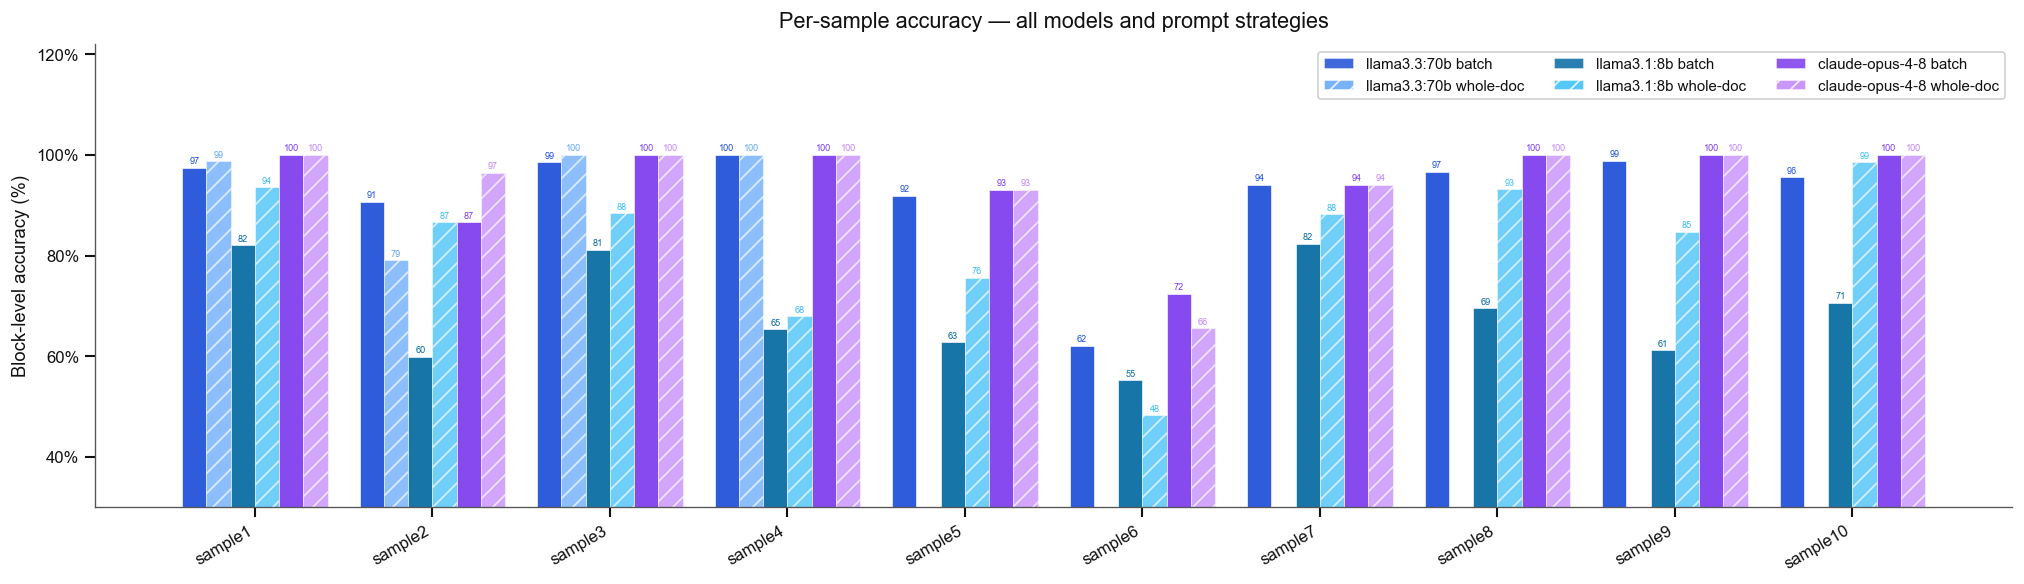

In [4]:
# ── Bar chart ───────────────────────────────────────────────────────────────────
n_v = len(ACTIVE)
w   = 0.82 / n_v
x   = list(range(len(SNAMES)))

fig, ax = plt.subplots(figsize=(17, 5))

for i, (name, (df, _)) in enumerate(ACTIVE.items()):
    cfg   = VARIANTS[name]
    alpha = 0.92 if cfg["hatch"] is None else 0.72
    vals  = [
        df[df["sample"] == s]["accuracy"].values[0] * 100
        if len(df[df["sample"] == s]) else 0
        for s in SNAMES
    ]
    offset = (i - n_v / 2 + 0.5) * w
    bars   = ax.bar(
        [xi + offset for xi in x], vals,
        width=w, label=name, color=cfg["color"],
        edgecolor="white", linewidth=0.4,
        alpha=alpha, hatch=cfg["hatch"]
    )
    for bar, v in zip(bars, vals):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
                    f"{v:.0f}", ha="center", va="bottom",
                    fontsize=5.5, color=cfg["color"])

ax.set_xticks(x)
ax.set_xticklabels(SNAMES, rotation=30, ha="right")
ax.set_ylim(30, 122)
ax.set_ylabel("Block-level accuracy (%)")
ax.set_title("Per-sample accuracy — all models and prompt strategies", pad=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))

# Legend: group by model family
handles = []
for mname, methods in MODEL_FAMILIES.items():
    for method, cfg in methods.items():
        vname = f"{mname} {method}"
        if vname in ACTIVE:
            p = mpatches.Patch(
                facecolor=cfg["color"], hatch=cfg["hatch"],
                edgecolor="white", label=vname, alpha=0.85
            )
            handles.append(p)

ax.legend(handles=handles, framealpha=0.9, ncol=3,
          loc="upper right", fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

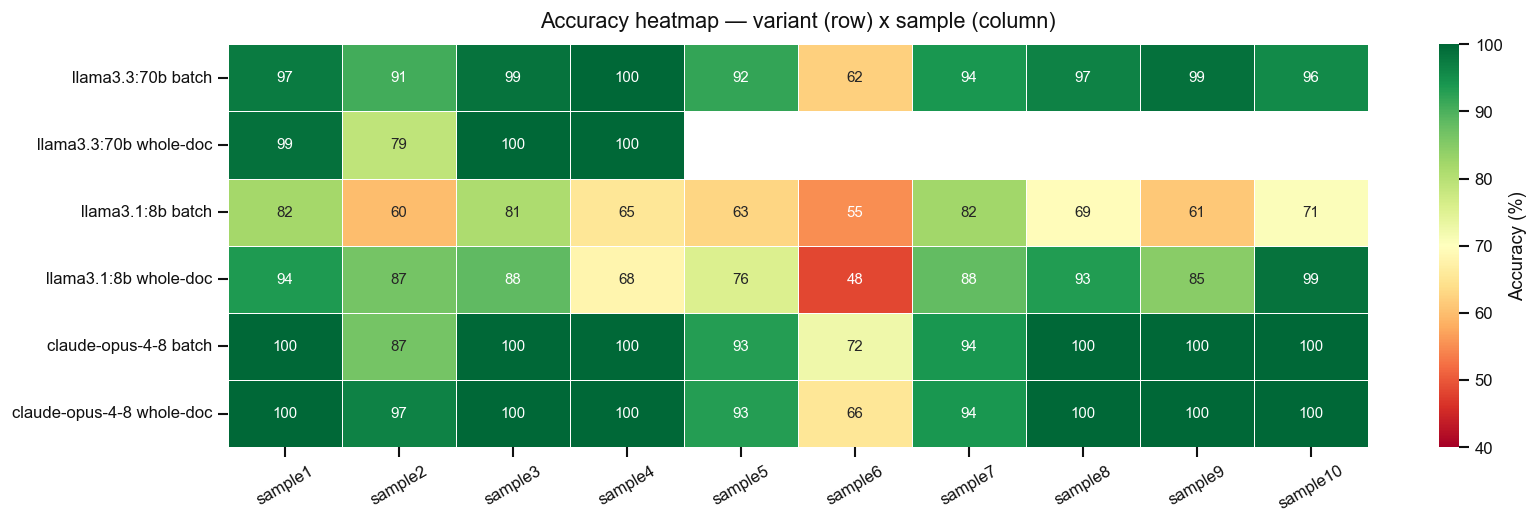

In [5]:
# ── Heatmap ──────────────────────────────────────────────────────────────────────
hmap_data = []
for name, (df, _) in ACTIVE.items():
    row = [
        df[df["sample"] == s]["accuracy"].values[0] * 100
        if len(df[df["sample"] == s]) else np.nan
        for s in SNAMES
    ]
    hmap_data.append(row)

hmap_df = pd.DataFrame(
    hmap_data, index=list(ACTIVE.keys()), columns=SNAMES
)

fig, ax = plt.subplots(figsize=(14, max(3, n_v * 0.75)))
sns.heatmap(
    hmap_df, annot=True, fmt=".0f", cmap="RdYlGn",
    vmin=40, vmax=100, linewidths=0.5, linecolor="white",
    ax=ax, cbar_kws={"label": "Accuracy (%)"},
    annot_kws={"size": 9}
)
ax.set_title("Accuracy heatmap — variant (row) x sample (column)", pad=10)
ax.tick_params(axis="x", rotation=30)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()

---
## Section 4 — F1 per label

F1 scores are computed over all 10 samples combined (micro-average per label).  
The two hardest labels are:
- **`question.text`** — funder requirement items (often look like `section.description` in a narrow window)
- **`section.description`** — funder background text (shares vocabulary with `question.text`)

The gap between batch and whole-doc for these two labels directly tests the hypothesis.

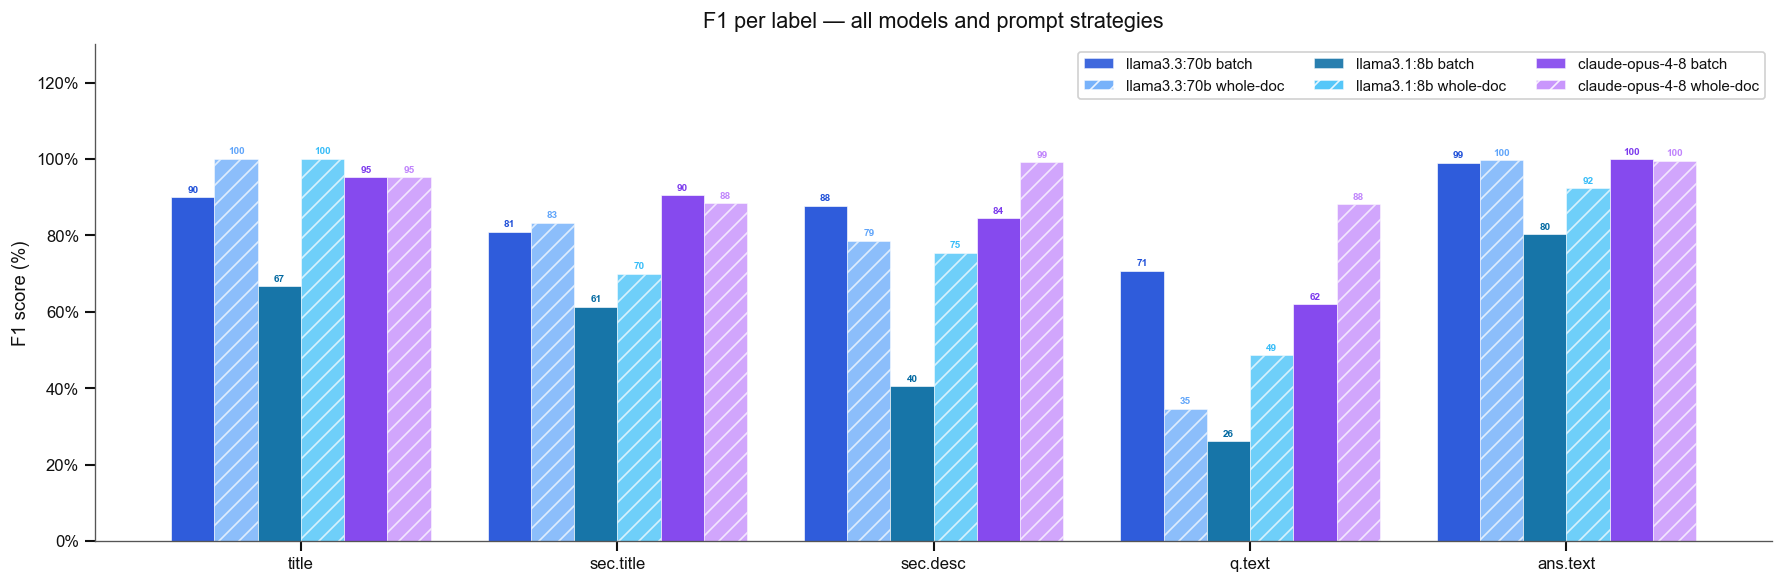


  Label                       llama3.3:70b batch  llama3.3:70b whole-doc       llama3.1:8b batch   llama3.1:8b whole-doc   claude-opus-4-8 batch  claude-opus-4-8 whole-doc
  ----------------------------------------------------------------------------------------------------------------------------------------------------------------------
  title                                    90.0%                  100.0%                   66.7%                  100.0%                   95.2%                   95.2%
  section.title                            80.9%                   83.3%                   61.3%                   70.0%                   90.5%                   88.4%
  section.description                      87.7%                   78.6%                   40.5%                   75.4%                   84.4%                   99.1%
  question.text                            70.7%                   34.6%                   26.1%                   48.6%                   62.0%       

In [6]:
x2 = list(range(len(LABELS)))
w2 = 0.82 / n_v

fig, ax = plt.subplots(figsize=(15, 5))

for i, (name, (_, conf)) in enumerate(ACTIVE.items()):
    cfg     = VARIANTS[name]
    alpha   = 0.92 if cfg["hatch"] is None else 0.72
    f1_vals = [_f1(conf, l) * 100 for l in LABELS]
    offset  = (i - n_v / 2 + 0.5) * w2
    bars    = ax.bar(
        [xi + offset for xi in x2], f1_vals,
        width=w2, label=name, color=cfg["color"],
        edgecolor="white", linewidth=0.4,
        alpha=alpha, hatch=cfg["hatch"]
    )
    for bar, v in zip(bars, f1_vals):
        if v > 2:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
                    f"{v:.0f}", ha="center", va="bottom",
                    fontsize=6, fontweight="bold", color=cfg["color"])

ax.set_xticks(x2)
ax.set_xticklabels(SHORT, fontsize=10)
ax.set_ylim(0, 130)
ax.set_ylabel("F1 score (%)")
ax.set_title("F1 per label — all models and prompt strategies", pad=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.legend(handles=handles, framealpha=0.9, ncol=3, fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

# F1 table
col_w = 22
print(f"\n  {'Label':<22}" + "".join(f"  {n:>{col_w}}" for n in ACTIVE))
print("  " + "-" * (22 + (col_w + 2) * n_v))
for lbl in LABELS:
    row = f"  {lbl:<22}"
    for name, (_, conf) in ACTIVE.items():
        row += f"  {_f1(conf, lbl)*100:>{col_w-1}.1f}%"
    print(row)

---
## Section 5 — Prompt strategy delta (batch → whole-doc)

For each model that has both batch and whole-doc data, this section shows:
- **Left panel:** Per-sample accuracy delta (positive = whole-doc better)
- **Right panel:** Net blocks changed across all samples

Models are shown side-by-side so you can compare how much each model benefits from full-document context.

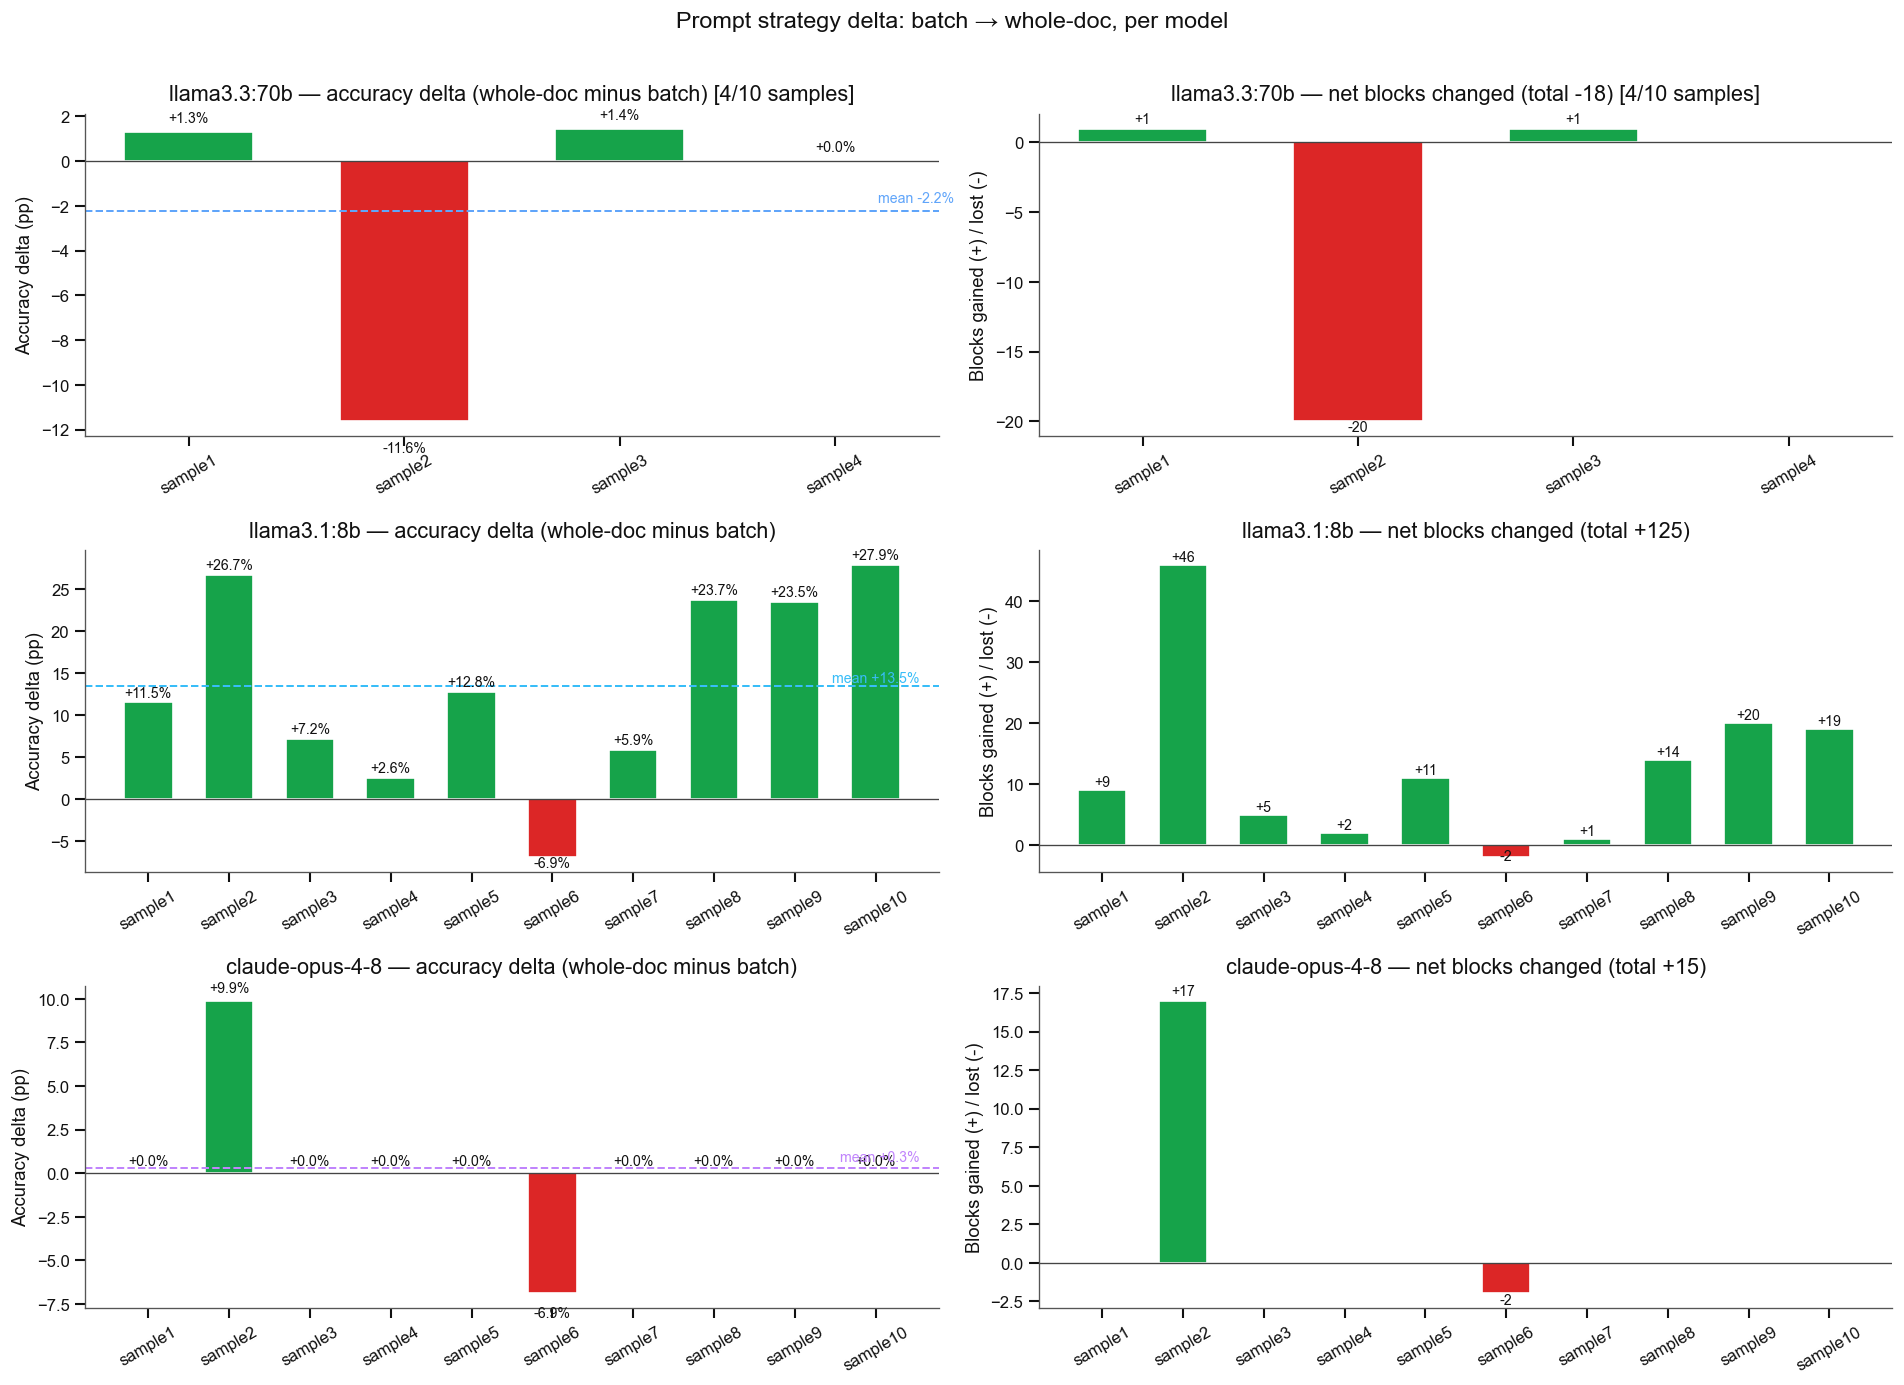


  llama3.3:70b  [4/10 samples compared]
  Sample           Batch   Whole-doc     Delta   Net blocks
  ---------------------------------------------------------
  sample1          97.4%       98.7%  +    1.3%  +         1
  sample2          90.7%       79.1%    -11.6%         -20
  sample3          98.6%      100.0%  +    1.4%  +         1
  sample4         100.0%      100.0%  +    0.0%  +         0
  ---------------------------------------------------------
  OVERALL          95.2%       90.7%     -4.5%         -18  [4/10]

  llama3.1:8b  [10/10 samples compared]
  Sample           Batch   Whole-doc     Delta   Net blocks
  ---------------------------------------------------------
  sample1          82.1%       93.6%  +   11.5%  +         9
  sample2          59.9%       86.6%  +   26.7%  +        46
  sample3          81.2%       88.4%  +    7.2%  +         5
  sample4          65.4%       67.9%  +    2.6%  +         2
  sample5          62.8%       75.6%  +   12.8%  +        11
  sa

In [7]:
# Find model families that have both batch and whole-doc available
comparable = [
    mname for mname in MODEL_FAMILIES
    if f"{mname} batch" in ACTIVE and f"{mname} whole-doc" in ACTIVE
]

if not comparable:
    print("No model families have both batch and whole-doc data yet.")
else:
    n_comp = len(comparable)
    fig, axes = plt.subplots(n_comp, 2, figsize=(16, 3.8 * n_comp),
                             squeeze=False)

    merged_cache = {}  # reuse for the detail tables below

    for row_i, mname in enumerate(comparable):
        df_b = ACTIVE[f"{mname} batch"][0]
        df_w = ACTIVE[f"{mname} whole-doc"][0]
        cfg_w = VARIANTS[f"{mname} whole-doc"]

        merged = (
            df_b[["sample", "accuracy", "correct", "total"]]
            .rename(columns={"accuracy": "acc_b", "correct": "cor_b", "total": "tot"})
            .merge(
                df_w[["sample", "accuracy", "correct"]]
                .rename(columns={"accuracy": "acc_w", "correct": "cor_w"}),
                on="sample"
            )
        )
        merged["delta"]  = merged["acc_w"] - merged["acc_b"]
        merged["gained"] = merged["cor_w"] - merged["cor_b"]
        merged = merged.sort_values("sample", key=lambda s: s.map(_snum))
        merged_cache[mname] = merged

        # Left: accuracy delta
        ax = axes[row_i][0]
        bar_colors = ["#16a34a" if d >= 0 else "#dc2626" for d in merged["delta"]]
        bars = ax.bar(merged["sample"], merged["delta"] * 100,
                      color=bar_colors, edgecolor="white", width=0.6)
        for bar, d in zip(bars, merged["delta"] * 100):
            ypos = bar.get_height() + (0.3 if d >= 0 else -1.5)
            ax.text(bar.get_x() + bar.get_width() / 2, ypos,
                    f"{'+' if d>=0 else ''}{d:.1f}%",
                    ha="center", va="bottom", fontsize=8.5)
        ax.axhline(0, color="#444", linewidth=0.8)
        avg = merged["delta"].mean() * 100
        ax.axhline(avg, color=cfg_w["color"], linestyle="--", linewidth=1.2)
        ax.text(len(merged) - 0.45, avg + 0.4,
                f"mean {avg:+.1f}%", ha="right", fontsize=8.5, color=cfg_w["color"])
        n_note = f" [{len(merged)}/10 samples]" if len(merged) < 10 else ""
        ax.set_ylabel("Accuracy delta (pp)")
        ax.set_title(f"{mname} — accuracy delta (whole-doc minus batch){n_note}", pad=8)
        ax.tick_params(axis="x", rotation=30)
        sns.despine(ax=ax)

        # Right: net blocks
        ax = axes[row_i][1]
        blk_colors = ["#16a34a" if g > 0 else ("#dc2626" if g < 0 else "#94a3b8")
                      for g in merged["gained"]]
        ax.bar(merged["sample"], merged["gained"],
               color=blk_colors, edgecolor="white", width=0.6)
        for xi, (_, r) in enumerate(merged.iterrows()):
            if r["gained"] != 0:
                ypos = r["gained"] + (0.15 if r["gained"] > 0 else -0.9)
                ax.text(xi, ypos,
                        f"{'+' if r['gained']>0 else ''}{int(r['gained'])}",
                        ha="center", va="bottom", fontsize=8.5)
        ax.axhline(0, color="#444", linewidth=0.8)
        net_total = int(merged["gained"].sum())
        ax.set_ylabel("Blocks gained (+) / lost (-)")
        ax.set_title(f"{mname} — net blocks changed (total {net_total:+d}){n_note}", pad=8)
        ax.tick_params(axis="x", rotation=30)
        sns.despine(ax=ax)

    plt.suptitle("Prompt strategy delta: batch → whole-doc, per model",
                 fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

    # Detailed tables
    for mname in comparable:
        merged = merged_cache[mname]
        n_s = len(merged)
        print(f"\n  {mname}  [{n_s}/10 samples compared]")
        print(f"  {'Sample':<12}  {'Batch':>8}  {'Whole-doc':>10}  {'Delta':>8}  {'Net blocks':>11}")
        print("  " + "-" * 57)
        for _, r in merged.iterrows():
            print(f"  {r['sample']:<12}  {r['acc_b']*100:>7.1f}%"
                  f"  {r['acc_w']*100:>9.1f}%"
                  f"  {'+' if r['delta']>=0 else ''}{r['delta']*100:>7.1f}%"
                  f"  {'+' if r['gained']>=0 else ''}{int(r['gained']):>10}")
        print("  " + "-" * 57)
        # OVERALL only over the matched samples
        tot = merged["tot"].sum()
        cb  = merged["cor_b"].sum()
        cw  = merged["cor_w"].sum()
        net = int(cw - cb)
        print(f"  {'OVERALL':<12}  {cb/tot*100:>7.1f}%"
              f"  {cw/tot*100:>9.1f}%"
              f"  {'+' if (cw-cb)>=0 else ''}{(cw-cb)/tot*100:>7.1f}%"
              f"  {'+' if net>=0 else ''}{net:>10}"
              + (f"  [{n_s}/10]" if n_s < 10 else ""))

---
## Section 6 — Block-level analysis

For each model family that has both strategies, this section breaks down **which specific blocks changed** from batch to whole-doc.  

- **Gained:** whole-doc correct, batch wrong  
- **Lost:** whole-doc wrong, batch correct  

The confusion shift table shows the label pairs involved — revealing *what kind* of error whole-doc fixes or introduces.

In [8]:
def block_level_comparison(mname):
    """Return (block_df, gained_df, lost_df) for a model family."""
    tag_b = VARIANTS[f"{mname} batch"]["tag"]
    tag_w = VARIANTS[f"{mname} whole-doc"]["tag"]
    rows  = []
    for mp in SAMPLES:
        stem  = mp.stem.replace("_dmp", "")
        gold  = extract_gold(mp)
        pp_b  = LLM_DIR / f"{stem}_{tag_b}.json"
        pp_w  = LLM_DIR / f"{stem}_{tag_w}.json"
        if not (pp_b.exists() and pp_w.exists()): continue
        blks_b = json.loads(pp_b.read_text(encoding="utf-8"))
        blks_w = json.loads(pp_w.read_text(encoding="utf-8"))
        for i, (bb, bw) in enumerate(zip(blks_b, blks_w)):
            true_lbl = match(bb["text"], gold)
            if true_lbl is None: continue
            lb, lw = bb.get("label", "answer.text"), bw.get("label", "answer.text")
            rows.append({
                "sample":     stem,
                "block_id":   i,
                "page":       bb.get("page", "-"),
                "text":       bb["text"][:80],
                "gold":       true_lbl,
                "pred_batch": lb,
                "pred_whole": lw,
                "batch_ok":   lb == true_lbl,
                "whole_ok":   lw == true_lbl,
            })
    df     = pd.DataFrame(rows)
    gained = df[ df["whole_ok"] & ~df["batch_ok"]]
    lost   = df[~df["whole_ok"] &  df["batch_ok"]]
    return df, gained, lost

BLOCK_DATA = {}
for mname in comparable:
    df, gained, lost = block_level_comparison(mname)
    BLOCK_DATA[mname] = (df, gained, lost)
    print(f"{mname}:")
    print(f"  Total matched blocks : {len(df)}")
    print(f"  Both correct         : {(df['whole_ok'] & df['batch_ok']).sum()}")
    print(f"  Gained (whole-doc +) : {len(gained)}")
    print(f"  Lost   (whole-doc -) : {len(lost)}")
    print(f"  Both wrong           : {(~df['whole_ok'] & ~df['batch_ok']).sum()}")
    print(f"  Net change           : {len(gained)-len(lost):+d}")
    print()

llama3.3:70b:
  Total matched blocks : 396
  Both correct         : 357
  Gained (whole-doc +) : 3
  Lost   (whole-doc -) : 21
  Both wrong           : 15
  Net change           : -18



llama3.1:8b:
  Total matched blocks : 726
  Both correct         : 454
  Gained (whole-doc +) : 170
  Lost   (whole-doc -) : 45
  Both wrong           : 57
  Net change           : +125



claude-opus-4-8:
  Total matched blocks : 726
  Both correct         : 699
  Gained (whole-doc +) : 19
  Lost   (whole-doc -) : 4
  Both wrong           : 4
  Net change           : +15



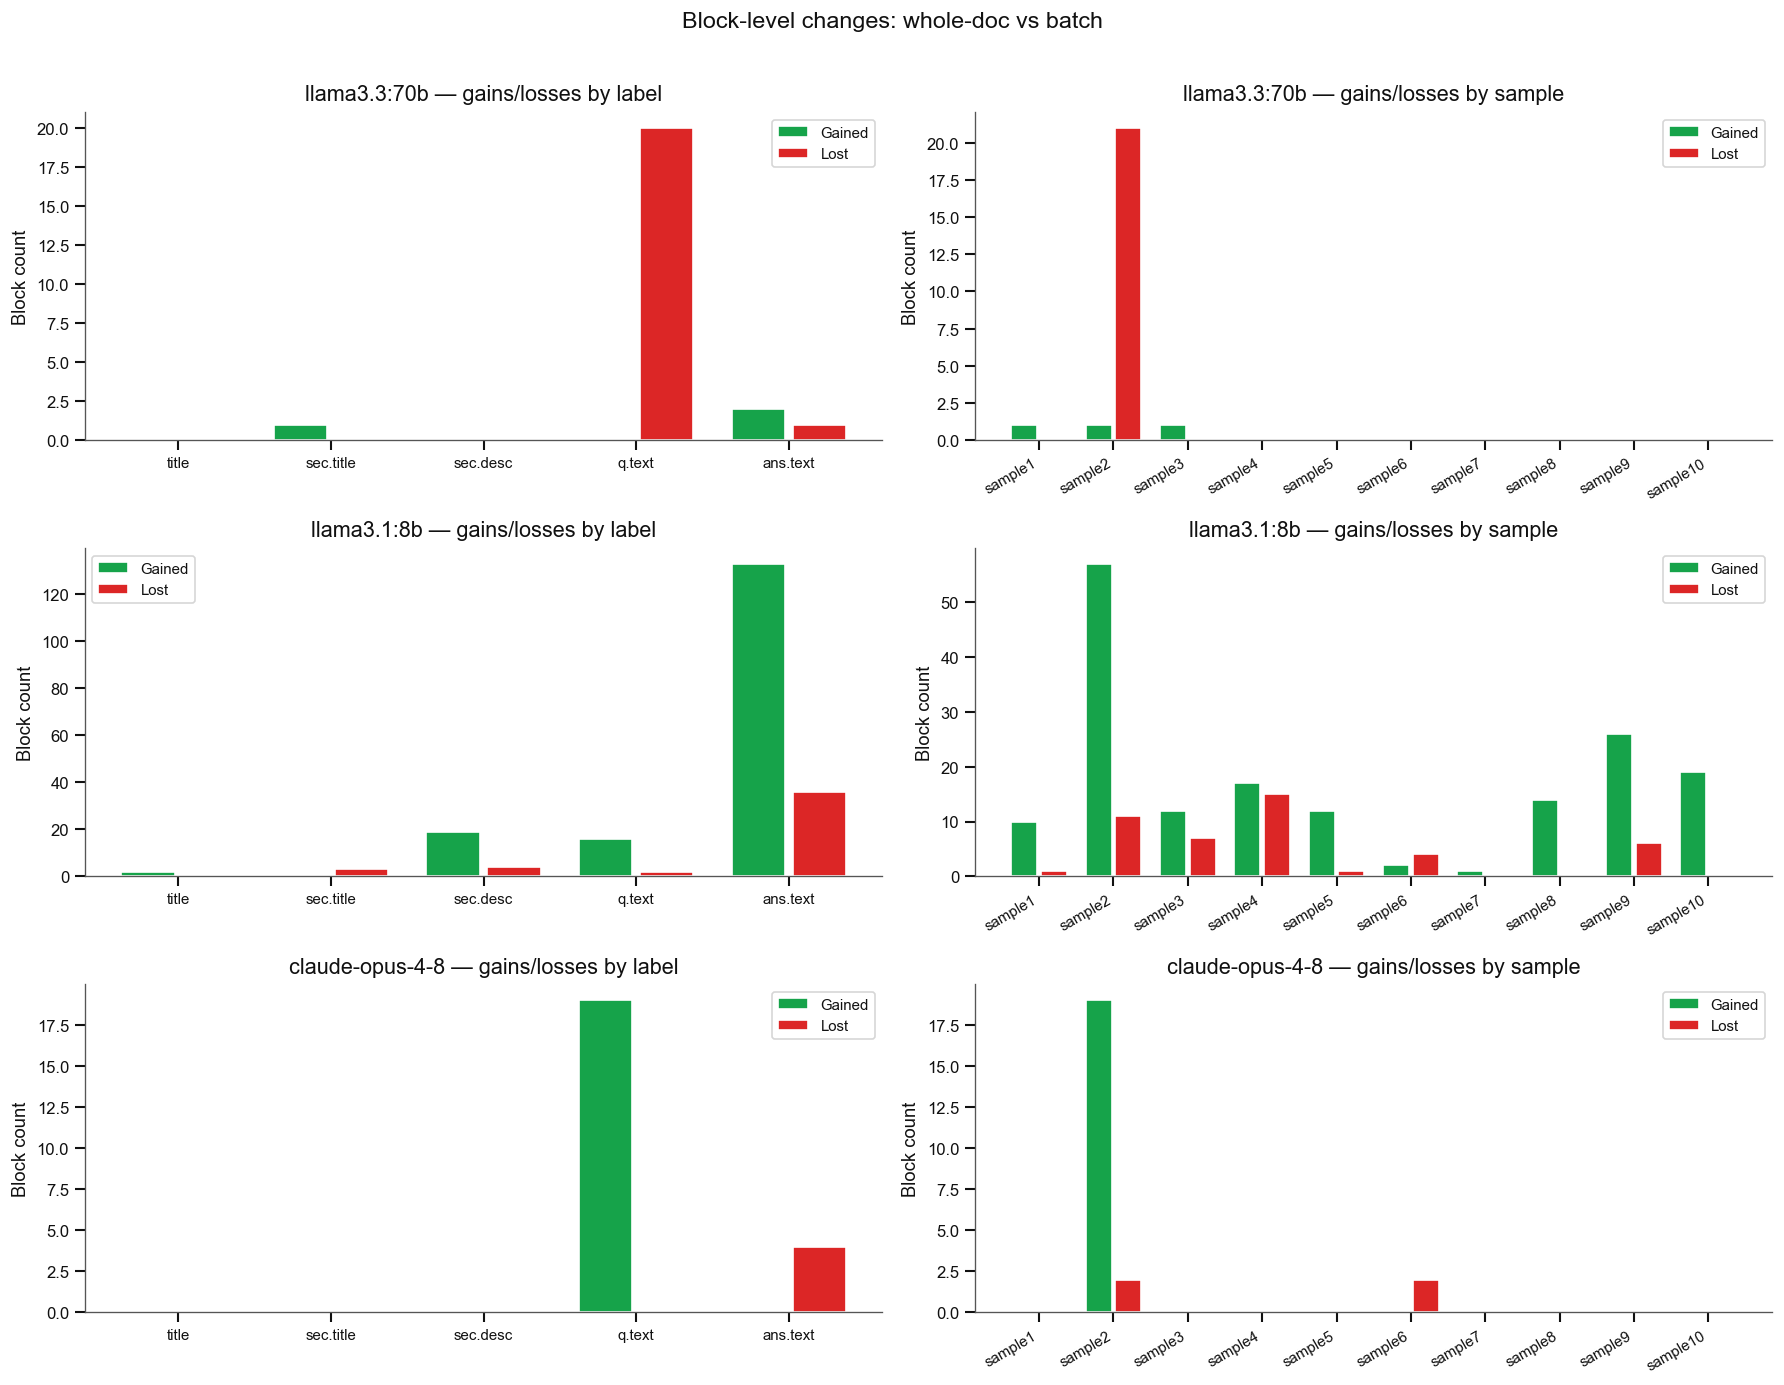


  llama3.3:70b
  Errors fixed by whole-doc (gold → batch prediction → fixed):
               answer.text  misclassified as  question.text           x 1
               answer.text  misclassified as  section.description     x 1
             section.title  misclassified as  question.text           x 1
  Errors introduced by whole-doc (gold → whole-doc prediction):
             question.text  misclassified as  section.description     x 19
               answer.text  misclassified as  question.text           x 1
             question.text  misclassified as  section.title           x 1

  llama3.1:8b
  Errors fixed by whole-doc (gold → batch prediction → fixed):
               answer.text  misclassified as  question.text           x 53
               answer.text  misclassified as  section.description     x 50
               answer.text  misclassified as  section.title           x 24
             question.text  misclassified as  section.description     x 10
       section.description  miscla

In [9]:
# Gains/losses breakdown: by label and by sample — one row per model
if BLOCK_DATA:
    n_m   = len(BLOCK_DATA)
    fig, axes = plt.subplots(n_m, 2, figsize=(15, 3.8 * n_m), squeeze=False)

    for row_i, (mname, (df, gained, lost)) in enumerate(BLOCK_DATA.items()):
        cfg_w = VARIANTS[f"{mname} whole-doc"]

        # By label
        ax = axes[row_i][0]
        lbl_g = gained["gold"].value_counts().reindex(LABELS, fill_value=0)
        lbl_l = lost["gold"].value_counts().reindex(LABELS, fill_value=0)
        xi    = list(range(len(LABELS)))
        ax.bar([i - 0.2 for i in xi], lbl_g, 0.35,
               label="Gained", color="#16a34a", edgecolor="white")
        ax.bar([i + 0.2 for i in xi], lbl_l, 0.35,
               label="Lost",   color="#dc2626", edgecolor="white")
        ax.set_xticks(xi); ax.set_xticklabels(SHORT, fontsize=9)
        ax.set_ylabel("Block count")
        ax.set_title(f"{mname} — gains/losses by label", pad=7)
        ax.legend(fontsize=9); sns.despine(ax=ax)

        # By sample
        ax = axes[row_i][1]
        samp_g = gained["sample"].value_counts().reindex(SNAMES, fill_value=0)
        samp_l = lost["sample"].value_counts().reindex(SNAMES, fill_value=0)
        xi2    = list(range(len(SNAMES)))
        ax.bar([i - 0.2 for i in xi2], samp_g, 0.35,
               label="Gained", color="#16a34a", edgecolor="white")
        ax.bar([i + 0.2 for i in xi2], samp_l, 0.35,
               label="Lost",   color="#dc2626", edgecolor="white")
        ax.set_xticks(xi2)
        ax.set_xticklabels(SNAMES, rotation=30, ha="right", fontsize=9)
        ax.set_ylabel("Block count")
        ax.set_title(f"{mname} — gains/losses by sample", pad=7)
        ax.legend(fontsize=9); sns.despine(ax=ax)

    plt.suptitle("Block-level changes: whole-doc vs batch", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

    # Confusion shift summary
    for mname, (_, gained, lost) in BLOCK_DATA.items():
        print(f"\n{'='*60}")
        print(f"  {mname}")
        print(f"{'='*60}")
        if len(gained):
            print("  Errors fixed by whole-doc (gold → batch prediction → fixed):")
            tbl = (gained.groupby(["gold", "pred_batch"]).size()
                   .reset_index(name="count")
                   .sort_values("count", ascending=False))
            for _, r in tbl.iterrows():
                print(f"    {r['gold']:>22}  misclassified as  {r['pred_batch']:<22}  x {r['count']}")
        if len(lost):
            print("  Errors introduced by whole-doc (gold → whole-doc prediction):")
            tbl = (lost.groupby(["gold", "pred_whole"]).size()
                   .reset_index(name="count")
                   .sort_values("count", ascending=False))
            for _, r in tbl.iterrows():
                print(f"    {r['gold']:>22}  misclassified as  {r['pred_whole']:<22}  x {r['count']}")

In [10]:
# Show actual gained/lost blocks (all models)
pd.set_option("display.max_colwidth", 80)
for mname, (_, gained, lost) in BLOCK_DATA.items():
    print(f"\n{'='*70}")
    print(f"  {mname}  —  {len(gained)} gained, {len(lost)} lost")
    print(f"{'='*70}")
    if len(gained):
        print(f"  GAINED (whole-doc correct, batch wrong):")
        display(gained[["sample","page","gold","pred_batch","pred_whole","text"]]
                .reset_index(drop=True))
    if len(lost):
        print(f"  LOST (whole-doc wrong, batch correct):")
        display(lost[["sample","page","gold","pred_batch","pred_whole","text"]]
                .reset_index(drop=True))


  llama3.3:70b  —  3 gained, 21 lost
  GAINED (whole-doc correct, batch wrong):


,sample,page,gold,pred_batch,pred_whole,text
0,sample1,1,answer.text,question.text,answer.text,The following data will be created as a result of this project:
1,sample2,3,answer.text,section.description,answer.text,"principles of this Statement, data sharing should make digital research data..."
2,sample3,2,section.title,question.text,section.title,Policies for access and sharing and appropriate protection and privacy


  LOST (whole-doc wrong, batch correct):


,sample,page,gold,pred_batch,pred_whole,text
0,sample2,1,question.text,question.text,section.description,Content and Format. A statement of plans for data and metadata content and f...
1,sample2,2,question.text,question.text,section.description,the anticipated means for sharing and rationale for any restrictions on who ...
2,sample2,2,question.text,question.text,section.description,and under what conditions;
3,sample2,2,question.text,question.text,section.description,a timeline for sharing and preservation that addresses both the minimum leng...
4,sample2,2,question.text,question.text,section.description,will be available and any anticipated delay to data access after research fi...
5,sample2,2,question.text,question.text,section.description,"any special requirements for data sharing, for example, proprietary software..."
6,sample2,2,question.text,question.text,section.description,"or interpret data, applicable policies, provisions, and licenses for re-use ..."
7,sample2,2,question.text,question.text,section.description,"for the production of derivatives, including guidance for how data and data ..."
8,sample2,2,question.text,question.text,section.description,cited;
9,sample2,2,question.text,question.text,section.description,"any resources and capabilities (equipment, connections, systems, software, e..."



  llama3.1:8b  —  170 gained, 45 lost
  GAINED (whole-doc correct, batch wrong):


...

,sample,page,gold,pred_batch,pred_whole,text
0,sample1,1,question.text,question.text,section.title,"B. Scientific data that will be preserved and shared, and the rationale for ..."
1,sample2,1,answer.text,answer.text,question.text,"Roles & Responsibilities. For the proposed research, Director Samuel Stupp w..."
2,sample2,1,question.text,question.text,section.title,"Data Types and Sources. A brief, high-level description of the data to be ge..."
3,sample2,2,section.title,section.title,question.text,preservation;
4,sample2,3,answer.text,answer.text,section.title,"retention, and data management."
5,sample2,3,section.title,section.title,section.description,2. Data used in publications
6,sample2,4,section.description,section.description,question.text,DMPs should consult and reference available information about data managemen...
7,sample2,4,section.description,section.description,question.text,"used in the course of the proposed research. In particular, DMPs that explic..."
8,sample2,4,section.description,section.description,question.text,users should be accompanied by written approval from that facility. In deter...
9,sample2,4,section.description,section.description,question.text,"available for data management at Office of Science User Facilities, research..."



  claude-opus-4-8  —  19 gained, 4 lost
  GAINED (whole-doc correct, batch wrong):


,sample,page,gold,pred_batch,pred_whole,text
0,sample2,2,question.text,section.description,question.text,"This should include, where appropriate:"
1,sample2,2,question.text,section.description,question.text,the anticipated means for sharing and rationale for any restrictions on who ...
2,sample2,2,question.text,section.description,question.text,and under what conditions;
3,sample2,2,question.text,section.description,question.text,a timeline for sharing and preservation that addresses both the minimum leng...
4,sample2,2,question.text,section.description,question.text,will be available and any anticipated delay to data access after research fi...
5,sample2,2,question.text,section.description,question.text,"any special requirements for data sharing, for example, proprietary software..."
6,sample2,2,question.text,section.description,question.text,"or interpret data, applicable policies, provisions, and licenses for re-use ..."
7,sample2,2,question.text,section.description,question.text,"for the production of derivatives, including guidance for how data and data ..."
8,sample2,2,question.text,section.description,question.text,cited;
9,sample2,2,question.text,section.description,question.text,"any resources and capabilities (equipment, connections, systems, software, e..."


  LOST (whole-doc wrong, batch correct):


,sample,page,gold,pred_batch,pred_whole,text
0,sample2,1,answer.text,answer.text,question.text,"Roles & Responsibilities. For the proposed research, Director Samuel Stupp w..."
1,sample2,4,answer.text,answer.text,question.text,"Data Volume. Generally, the volume of data generated by CBES researchers sho..."
2,sample6,1,answer.text,answer.text,section.title,"1. Types of data. The bulk of the data generated in this project will be 1, ..."
3,sample6,1,answer.text,answer.text,section.title,3. Policies for access and sharing. Interested parties will be able to reque...


---
## Section 7 — Summary and conclusions

In [11]:
print("=" * 70)
print("  Experiment 01 — Prompt Strategy Comparison Across Models")
print("  10 DMP samples · 5 labels · block-level evaluation")
print("=" * 70)
print()

# Overall accuracy and key label F1 for all active variants
print(f"  {'Variant':<32}  {'Accuracy':>9}  {'q.text F1':>10}  {'sec.desc F1':>12}")
print("  " + "-" * 70)
for name, (df, conf) in ACTIVE.items():
    tc, tn = int(df["correct"].sum()), int(df["total"].sum())
    f1_qt  = _f1(conf, "question.text")       * 100
    f1_sd  = _f1(conf, "section.description") * 100
    marker = "  <-- best" if tc/tn == max(
        ACTIVE[n][0]["correct"].sum() / ACTIVE[n][0]["total"].sum()
        for n in ACTIVE
    ) else ""
    print(f"  {name:<32}  {tc/tn*100:>8.1f}%  {f1_qt:>9.1f}%  {f1_sd:>11.1f}%{marker}")

print()
print("  Prompt strategy effect (batch → whole-doc):")
for mname in comparable:
    df_b, conf_b = ACTIVE[f"{mname} batch"]
    df_w, conf_w = ACTIVE[f"{mname} whole-doc"]
    _, gained, lost = BLOCK_DATA[mname]
    acc_b = df_b["correct"].sum() / df_b["total"].sum() * 100
    acc_w = df_w["correct"].sum() / df_w["total"].sum() * 100
    dqt   = (_f1(conf_w, "question.text")       - _f1(conf_b, "question.text"))       * 100
    dsd   = (_f1(conf_w, "section.description") - _f1(conf_b, "section.description")) * 100
    print(f"    {mname:<20}  acc {acc_b:.1f}% -> {acc_w:.1f}% ({acc_w-acc_b:+.1f}pp)  "
          f"q.text {dqt:+.1f}pp  sec.desc {dsd:+.1f}pp  "
          f"net blocks {len(gained)-len(lost):+d}")

print()
print("  Pending (no whole-doc data yet):")
pending = [mname for mname in MODEL_FAMILIES if mname not in comparable
           and f"{mname} batch" in ACTIVE]
for mname in pending:
    tag_w = VARIANTS[f"{mname} whole-doc"]["tag"]
    print(f"    {mname:<20}  run: python run_wholedoc_ollama.py --model {mname.replace('llama', 'llama')}")
if not pending:
    print("    None — all variants available.")

print()
print("=" * 70)

  Experiment 01 — Prompt Strategy Comparison Across Models
  10 DMP samples · 5 labels · block-level evaluation

  Variant                            Accuracy   q.text F1   sec.desc F1
  ----------------------------------------------------------------------
  llama3.3:70b batch                    94.1%       70.7%         87.7%
  llama3.3:70b whole-doc                90.7%       34.6%         78.6%
  llama3.1:8b batch                     67.3%       26.1%         40.5%
  llama3.1:8b whole-doc                 84.2%       48.6%         75.4%
  claude-opus-4-8 batch                 94.9%       62.0%         84.4%
  claude-opus-4-8 whole-doc             96.9%       88.2%         99.1%  <-- best

  Prompt strategy effect (batch → whole-doc):
    llama3.3:70b          acc 94.1% -> 90.7% (-3.4pp)  q.text -36.1pp  sec.desc -9.1pp  net blocks -18
    llama3.1:8b           acc 67.3% -> 84.2% (+16.9pp)  q.text +22.4pp  sec.desc +34.9pp  net blocks +125
    claude-opus-4-8       acc 94.9% -> 96.9%